In [12]:
# === Cell 1: Import libraries and load data ===
# Rationale: Self-contained notebook — reload everything from scratch
# so anyone can run this independently.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display

# Load and clean data
metadata = pd.read_csv('../data/metadata.csv', sep=';')
asv_table = pd.read_excel('../data/seqtab_nochim_export.xlsx')
asv_table = asv_table.rename(columns={'Unnamed: 0': 'SampleID'}).set_index('SampleID')

print(f"ASV table: {asv_table.shape[0]} samples x {asv_table.shape[1]} ASVs")
print(f"Disease groups: {dict(metadata['DiseaseStatus'].value_counts())}")

ASV table: 59 samples x 6693 ASVs
Disease groups: {'Colorectal cancer': np.int64(21), 'Healthy': np.int64(19), 'Adenomatous Polyps': np.int64(19)}


In [13]:
# === Cell 2: Data Preparation ===
# Rationale: Raw ASV counts are not directly comparable across samples because
# sequencing depth varies. We need to:
#   1. Load taxonomy and map each ASV to its phylum
#   2. Aggregate counts at phylum level (6693 ASVs → 13 phyla)
#   3. Normalize to relative abundance (each sample sums to 1)
#   4. Filter out phyla present in <10% of samples (remove rare, unreliable features)

# --- Load taxonomy ---
taxonomy = pd.read_excel('../data/taxa_species_export.xlsx')
taxonomy = taxonomy.rename(columns={'Unnamed: 0': 'ASV'}).set_index('ASV')

# --- Aggregate ASV counts to phylum level ---
# Drop ASVs with no phylum assignment (unclassified, 269 out of 6693)
phylum_map = taxonomy['Phylum'].dropna()
asv_classified = asv_table[asv_table.columns.intersection(phylum_map.index)]
phylum_counts = asv_classified.T.groupby(phylum_map).sum().T  # samples x phyla

# --- Relative normalization ---
# Divide each sample by its row total so values represent proportions (0–1)
phylum_rel = phylum_counts.div(phylum_counts.sum(axis=1), axis=0)

# --- Prevalence filtering ---
# Keep phyla present (abundance > 0) in at least 10% of samples (~6 out of 59)
prevalence = (phylum_rel > 0).mean(axis=0)
phylum_filtered = phylum_rel.loc[:, prevalence >= 0.10]

# --- Attach disease group labels ---
# The ASV table index uses host_disease IDs (e.g. CRC1, Healthy1), not SampleID (SRR...)
meta = metadata.set_index('host_disease')[['DiseaseStatus']]
phylum_df = phylum_filtered.join(meta)

print(f"Phyla after filtering: {phylum_filtered.shape[1]} / {phylum_rel.shape[1]}")
print(f"Retained phyla: {phylum_filtered.columns.tolist()}")
display(phylum_filtered.describe().round(4))

Phyla after filtering: 11 / 13
Retained phyla: ['Actinobacteriota', 'Bacteroidota', 'Campylobacterota', 'Cyanobacteria', 'Desulfobacterota', 'Euryarchaeota', 'Firmicutes', 'Fusobacteriota', 'Patescibacteria', 'Proteobacteria', 'Verrucomicrobiota']


Phylum,Actinobacteriota,Bacteroidota,Campylobacterota,Cyanobacteria,Desulfobacterota,Euryarchaeota,Firmicutes,Fusobacteriota,Patescibacteria,Proteobacteria,Verrucomicrobiota
count,59.0000,59.0000,59.0000,59.0000,59.0000,59.0000,59.0000,59.0000,59.0000,59.0000,59.0000
mean,0.0230,0.0025,0.0091,0.0006,0.0001,0.0015,0.7695,0.0771,0.0004,0.1069,0.0088
std,0.0160,0.0041,0.0577,0.0012,0.0002,0.0030,0.2240,0.1848,0.0016,0.1487,0.0261
min,0.0025,0.0000,0.0000,0.0000,0.0000,0.0000,0.1947,0.0000,0.0000,0.0023,0.0000
25%,0.0132,0.0001,0.0000,0.0000,0.0000,0.0000,0.6395,0.0000,0.0000,0.0204,0.0000
50%,0.0186,0.0008,0.0000,0.0000,0.0000,0.0000,0.8847,0.0033,0.0000,0.0344,0.0000
75%,0.0275,0.0027,0.0000,0.0008,0.0000,0.0002,0.9347,0.0300,0.0002,0.1392,0.0015
max,0.0774,0.0189,0.4421,0.0049,0.0013,0.0128,0.9784,0.7835,0.0116,0.5799,0.1553


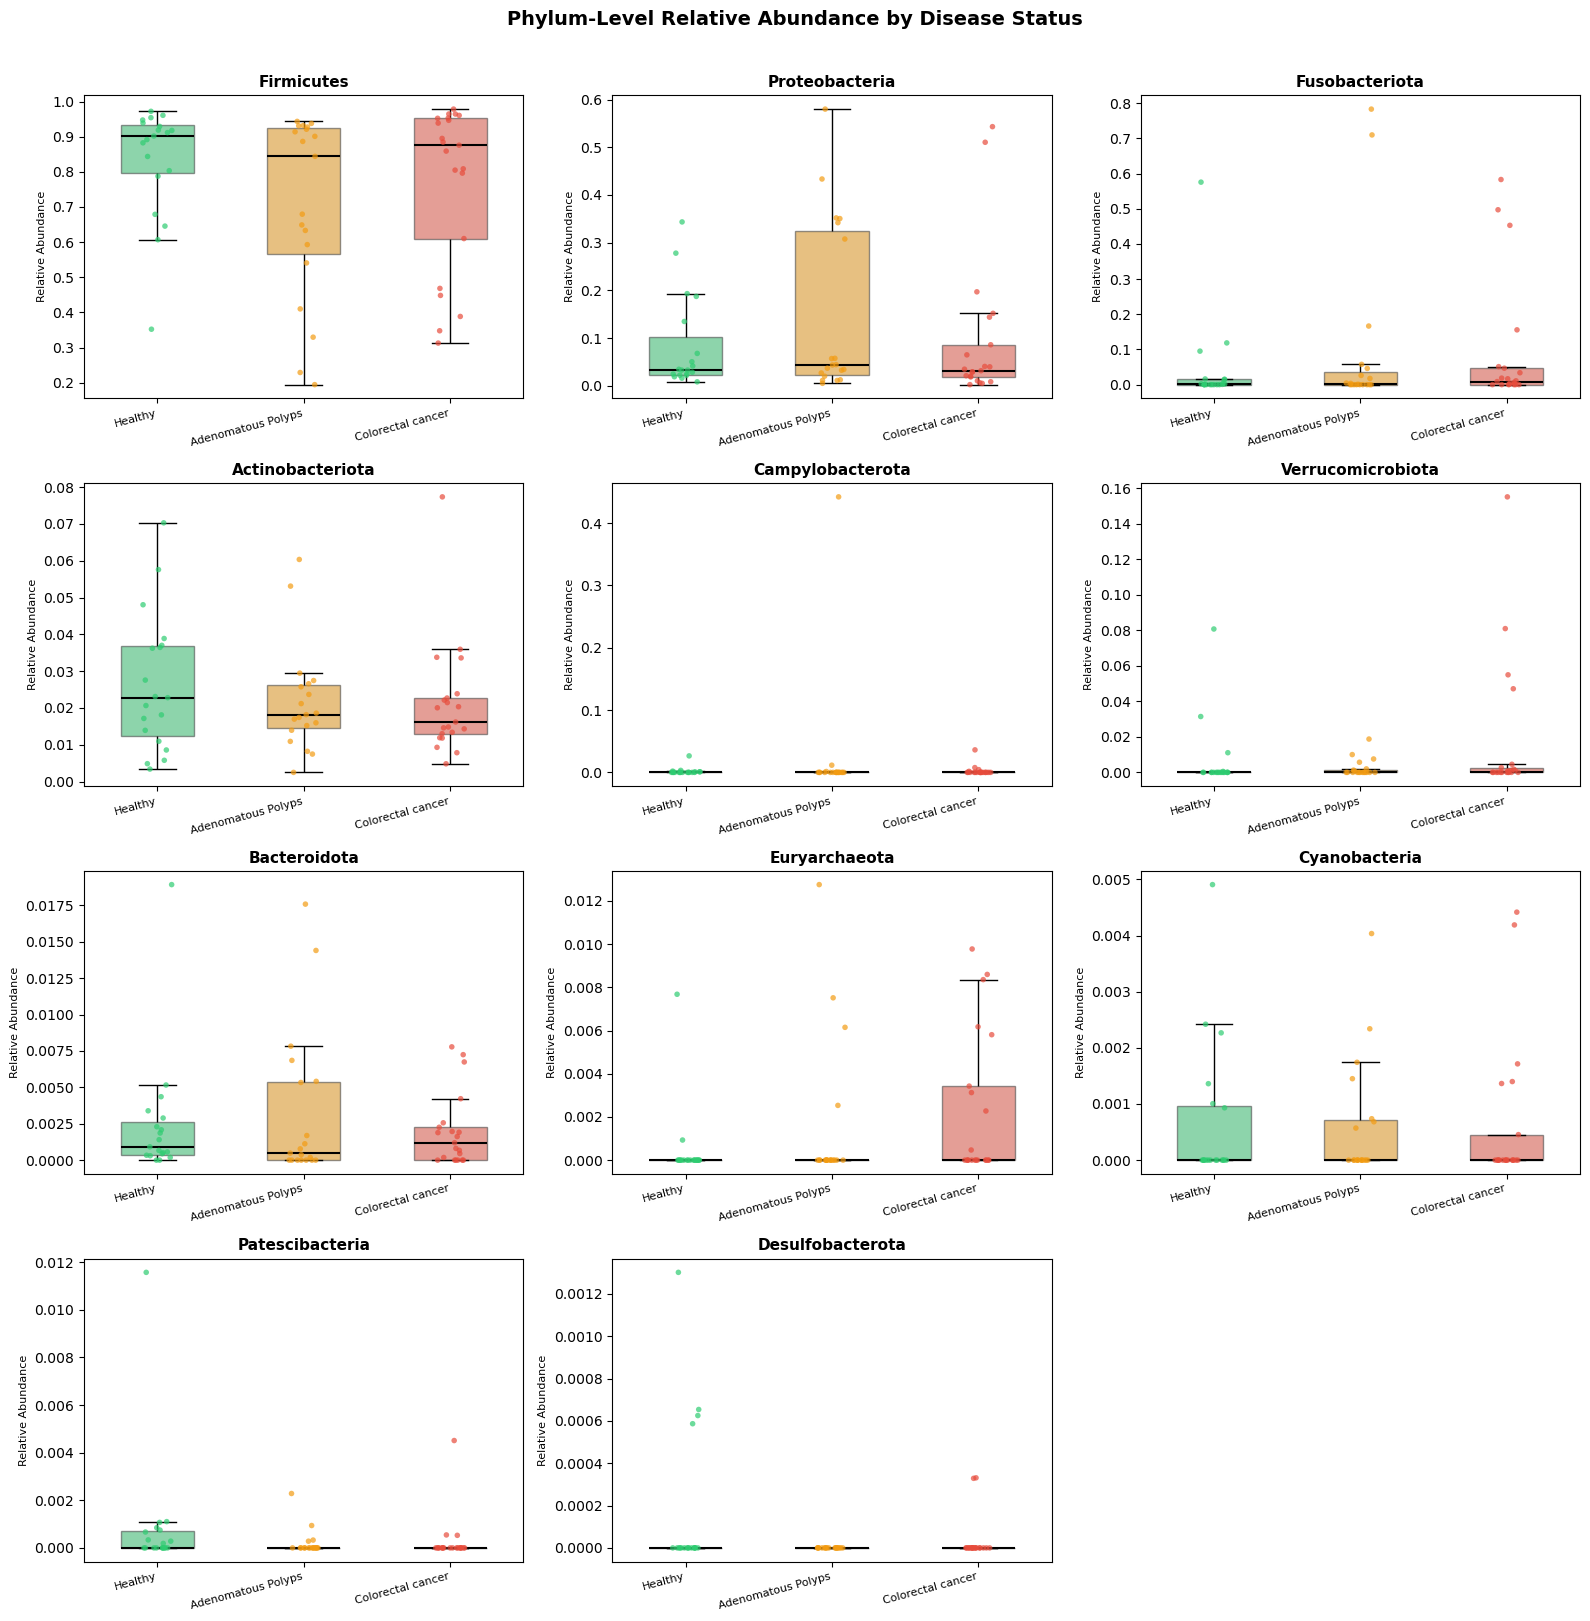

Figure saved to ../figures/04_phylum_boxplots.png


In [14]:
# === Cell 3: Phylum-Level Abundance Boxplots ===
# Rationale: Before running any statistical test, visualize the raw distributions.
# Boxplots per group let us spot which phyla look different across disease stages
# and whether the variation is driven by outliers or a true group-level shift.
# Phyla are sorted by overall mean abundance (most dominant first).

colors = {
    'Healthy': '#2ecc71',
    'Adenomatous Polyps': '#f39c12',
    'Colorectal cancer': '#e74c3c'
}
group_order = ['Healthy', 'Adenomatous Polyps', 'Colorectal cancer']

# Sort phyla by descending mean abundance for a readable layout
phyla_sorted = phylum_filtered.mean().sort_values(ascending=False).index.tolist()

n_phyla = len(phyla_sorted)
ncols = 3
nrows = (n_phyla + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, phylum in enumerate(phyla_sorted):
    ax = axes[i]

    sns.boxplot(data=phylum_df, x='DiseaseStatus', y=phylum,
                order=group_order, palette=colors, ax=ax,
                showfliers=False, width=0.5,
                boxprops=dict(alpha=0.6),
                medianprops=dict(color='black', linewidth=1.5),
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'))

    sns.stripplot(data=phylum_df, x='DiseaseStatus', y=phylum,
                  order=group_order, palette=colors, ax=ax,
                  size=4, alpha=0.7, jitter=True, dodge=False)

    ax.set_title(phylum, fontsize=11, fontweight='bold')
    ax.set_xticklabels(group_order, rotation=15, ha='right', fontsize=8)
    ax.set_ylabel('Relative Abundance', fontsize=8)
    ax.set_xlabel('')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Phylum-Level Relative Abundance by Disease Status', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figures/04_phylum_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to ../figures/04_phylum_boxplots.png")

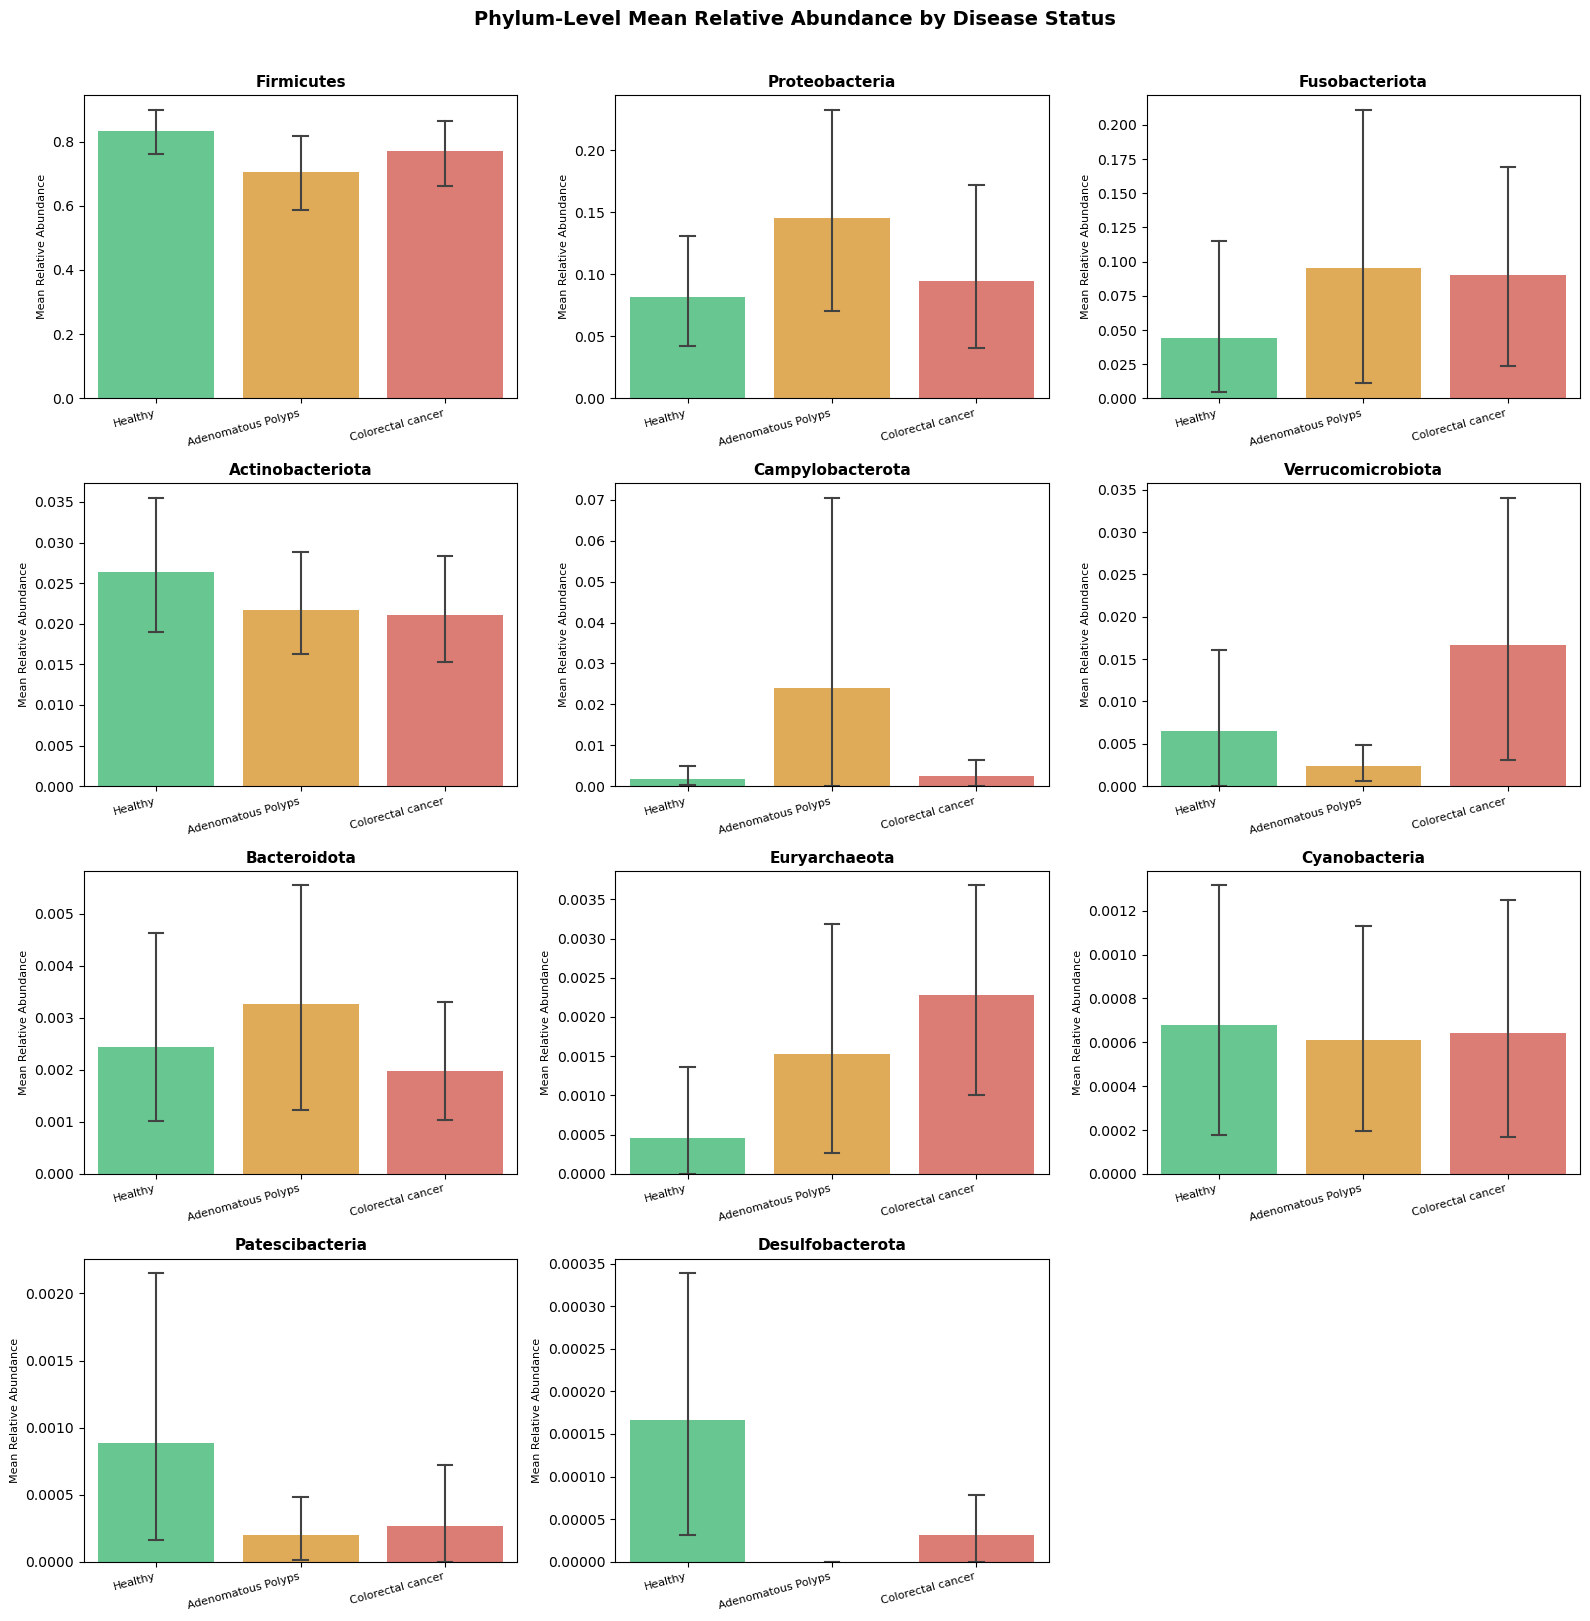

Figure saved to ../figures/04_phylum_barplots.png


In [15]:
# === Cell 4: Phylum-Level Abundance Bar Charts ===
# Rationale: Bar charts show mean relative abundance per group with 95% CI,
# making it easy to compare group-level averages and their uncertainty.
# Complements the boxplots above by emphasizing the central tendency.

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, phylum in enumerate(phyla_sorted):
    ax = axes[i]

    sns.barplot(data=phylum_df, x='DiseaseStatus', y=phylum,
                order=group_order, palette=colors, ax=ax,
                capsize=0.1, errwidth=1.5, alpha=0.8)

    ax.set_title(phylum, fontsize=11, fontweight='bold')
    ax.set_xticklabels(group_order, rotation=15, ha='right', fontsize=8)
    ax.set_ylabel('Mean Relative Abundance', fontsize=8)
    ax.set_xlabel('')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Phylum-Level Mean Relative Abundance by Disease Status', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figures/04_phylum_barplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to ../figures/04_phylum_barplots.png")

In [11]:
# === Cell 5: Statistical Testing of Differential Abundance ===
# Rationale: Kruskal-Wallis tests whether any group differs for each phylum.
# If significant, pairwise Mann-Whitney U identifies which pairs drive the effect.
# Bonferroni correction controls false positives across 3 pairwise comparisons.

from scipy.stats import kruskal, mannwhitneyu

pairs = [
    ('Healthy', 'Adenomatous Polyps'),
    ('Healthy', 'Colorectal cancer'),
    ('Adenomatous Polyps', 'Colorectal cancer'),
]
n_comparisons = len(pairs)

# --- Kruskal-Wallis ---
print("=== KRUSKAL-WALLIS TEST (3-group comparison) ===\n")
kw_results = {}
for phylum in phyla_sorted:
    group_data = [phylum_df[phylum_df['DiseaseStatus'] == g][phylum].values for g in group_order]
    stat, p = kruskal(*group_data)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    kw_results[phylum] = p
    print(f"{phylum:25s}  H={stat:.2f}  p={p:.4f}  {sig}")

# --- Pairwise Mann-Whitney U (Bonferroni corrected) ---
print("\n=== PAIRWISE MANN-WHITNEY U TESTS (Bonferroni corrected) ===\n")
for phylum in phyla_sorted:
    print(f"--- {phylum} ---")
    for g1, g2 in pairs:
        d1 = phylum_df[phylum_df['DiseaseStatus'] == g1][phylum].values
        d2 = phylum_df[phylum_df['DiseaseStatus'] == g2][phylum].values
        stat, p = mannwhitneyu(d1, d2, alternative='two-sided')
        p_corr = min(p * n_comparisons, 1.0)
        sig = '***' if p_corr < 0.001 else '**' if p_corr < 0.01 else '*' if p_corr < 0.05 else 'ns'
        print(f"  {g1} vs {g2}: U={stat:.0f}  p_corrected={p_corr:.4f}  {sig}")
    print()

=== KRUSKAL-WALLIS TEST (3-group comparison) ===

Firmicutes                 H=2.37  p=0.3061  ns
Proteobacteria             H=1.25  p=0.5354  ns
Fusobacteriota             H=2.21  p=0.3318  ns
Actinobacteriota           H=1.15  p=0.5617  ns
Campylobacterota           H=0.92  p=0.6322  ns
Verrucomicrobiota          H=2.71  p=0.2578  ns
Bacteroidota               H=0.38  p=0.8267  ns
Euryarchaeota              H=5.50  p=0.0641  ns
Cyanobacteria              H=0.16  p=0.9251  ns
Patescibacteria            H=5.74  p=0.0566  ns
Desulfobacterota           H=4.88  p=0.0870  ns

=== PAIRWISE MANN-WHITNEY U TESTS (Bonferroni corrected) ===

--- Firmicutes ---
  Healthy vs Adenomatous Polyps: U=231  p_corrected=0.4331  ns
  Healthy vs Colorectal cancer: U=213  p_corrected=1.0000  ns
  Adenomatous Polyps vs Colorectal cancer: U=158  p_corrected=0.8004  ns

--- Proteobacteria ---
  Healthy vs Adenomatous Polyps: U=157  p_corrected=1.0000  ns
  Healthy vs Colorectal cancer: U=220  p_corrected=1.00

### Differential Abundance — Results

Kruskal-Wallis tests found no significant differences between groups for any of the 11 retained phyla after Bonferroni correction. This is consistent with the alpha and beta diversity results from notebooks 02 and 03.

**Interpretation:** Phylum-level resolution is too coarse to capture the microbial shifts associated with colorectal cancer progression. CRC-associated taxa (e.g. *Fusobacterium nucleatum*, *Peptostreptococcus*, *Parvimonas*) represent a small fraction of total abundance that is masked at this level of aggregation. Finer taxonomic resolution (genus or species level) and ASV-level machine learning classification — the focus of the next notebook — are better suited to identify discriminant features between Healthy, Adenomatous Polyps, and Colorectal cancer groups.